# Calendar and Temporal Feature Engineering

## Objective

This notebook performs calendar-based and temporal feature engineering
for the M5 retail sales forecasting dataset.

The goal is to transform the existing calendar information into
machine-learning-ready temporal features without using future sales
information.

### Features considered

- Year
- Month
- Week
- Day of month
- Day of week
- Quarter
- Weekend indicator
- Month-start indicator
- Month-end indicator
- Year-start indicator
- Year-end indicator
- Existing M5 calendar/event features

### Leakage prevention

Only calendar information available for each date is used.
No future sales values are used to construct these features.

In [94]:
import sys
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if 'google.colab' in sys.modules:
    BASE = Path("/content")
else:
    BASE = Path("..").resolve()

sys.path.insert(0, str(BASE / "src"))

PROCESSED_PATH = BASE / "data" / "m5" / "processed"
RESULTS_PATH = BASE / "results"
SRC_PATH = BASE / "src"

print("Libraries imported successfully.")

Libraries imported successfully.


In [95]:
calendar_clean = pd.read_csv(
    PROCESSED_PATH / "calendar_clean.csv"
)

print("Calendar shape:", calendar_clean.shape)
print("\nColumns:")
print(calendar_clean.columns.tolist())

Calendar shape: (1969, 14)

Columns:
['date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'd', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI']


In [96]:
calendar_clean["date"] = pd.to_datetime(
    calendar_clean["date"],
    errors="coerce"
)

print("Date dtype:", calendar_clean["date"].dtype)
print("Invalid dates:", calendar_clean["date"].isna().sum())

Date dtype: datetime64[us]
Invalid dates: 0


In [97]:
print("Minimum date:", calendar_clean["date"].min())
print("Maximum date:", calendar_clean["date"].max())
print("Number of dates:", calendar_clean["date"].nunique())

Minimum date: 2011-01-29 00:00:00
Maximum date: 2016-06-19 00:00:00
Number of dates: 1969


In [98]:
feature_file = SRC_PATH / "feature_engineering.py"

if not feature_file.exists():
    feature_file.write_text(
        '''from pathlib import Path
import pandas as pd
import numpy as np


def load_calendar(calendar_path):
    """
    Load the cleaned M5 calendar dataset.
    """
    calendar_path = Path(calendar_path)

    calendar = pd.read_csv(calendar_path)

    calendar["date"] = pd.to_datetime(
        calendar["date"],
        errors="coerce"
    )

    return calendar
''',
        encoding="utf-8"
    )

    print("feature_engineering.py created successfully.")
else:
    print("feature_engineering.py already exists.")

feature_engineering.py already exists.


In [99]:
feature_file = SRC_PATH / "feature_engineering.py"

current_code = feature_file.read_text(
    encoding="utf-8"
)

temporal_function = '''

def create_calendar_features(calendar):
    """
    Create calendar-based temporal features.

    Parameters
    ----------
    calendar : pandas.DataFrame
        Cleaned M5 calendar dataset.

    Returns
    -------
    pandas.DataFrame
        Calendar dataset with engineered temporal features.
    """

    df = calendar.copy()

    # Ensure date is datetime
    df["date"] = pd.to_datetime(
        df["date"],
        errors="coerce"
    )

    # Basic temporal features
    df["year_feature"] = df["date"].dt.year
    df["month_feature"] = df["date"].dt.month
    df["day_feature"] = df["date"].dt.day
    df["day_of_week_feature"] = df["date"].dt.dayofweek
    df["quarter_feature"] = df["date"].dt.quarter
    df["week_of_year_feature"] = df["date"].dt.isocalendar().week.astype(int)

    # Calendar boundary features
    df["is_weekend"] = (
        df["date"].dt.dayofweek >= 5
    ).astype(int)

    df["is_month_start"] = (
        df["date"].dt.is_month_start
    ).astype(int)

    df["is_month_end"] = (
        df["date"].dt.is_month_end
    ).astype(int)

    df["is_quarter_start"] = (
        df["date"].dt.is_quarter_start
    ).astype(int)

    df["is_quarter_end"] = (
        df["date"].dt.is_quarter_end
    ).astype(int)

    df["is_year_start"] = (
        df["date"].dt.is_year_start
    ).astype(int)

    df["is_year_end"] = (
        df["date"].dt.is_year_end
    ).astype(int)

    return df
'''

if "def create_calendar_features" not in current_code:
    feature_file.write_text(
        current_code + temporal_function,
        encoding="utf-8"
    )

    print("create_calendar_features() added successfully.")
else:
    print("create_calendar_features() already exists.")

create_calendar_features() already exists.


In [100]:
import importlib
import feature_engineering

importlib.reload(feature_engineering)

from feature_engineering import (
    load_calendar,
    create_calendar_features
)

print("Feature-engineering functions imported successfully.")

Feature-engineering functions imported successfully.


In [101]:
calendar_features = create_calendar_features(
    calendar_clean
)

print("Original shape:", calendar_clean.shape)
print("Feature-engineered shape:", calendar_features.shape)

Original shape: (1969, 14)
Feature-engineered shape: (1969, 27)


In [102]:
new_columns = [
    column
    for column in calendar_features.columns
    if column not in calendar_clean.columns
]

print("New temporal features:")
print("-" * 50)

for column in new_columns:
    print(column)

New temporal features:
--------------------------------------------------
year_feature
month_feature
day_feature
day_of_week_feature
quarter_feature
week_of_year_feature
is_weekend
is_month_start
is_month_end
is_quarter_start
is_quarter_end
is_year_start
is_year_end


In [103]:
calendar_features[
    [
        "date",
        "year_feature",
        "month_feature",
        "day_feature",
        "day_of_week_feature",
        "quarter_feature",
        "week_of_year_feature",
        "is_weekend"
    ]
].head(15)

,date,year_feature,month_feature,day_feature,day_of_week_feature,quarter_feature,week_of_year_feature,is_weekend
0,2011-01-29,2011,1,29,5,1,4,1
1,2011-01-30,2011,1,30,6,1,4,1
2,2011-01-31,2011,1,31,0,1,5,0
3,2011-02-01,2011,2,1,1,1,5,0
4,2011-02-02,2011,2,2,2,1,5,0
5,2011-02-03,2011,2,3,3,1,5,0
6,2011-02-04,2011,2,4,4,1,5,0
7,2011-02-05,2011,2,5,5,1,5,1
8,2011-02-06,2011,2,6,6,1,5,1
9,2011-02-07,2011,2,7,0,1,6,0


In [104]:
print("Temporal Feature Validation")
print("=" * 60)

print(
    "Missing dates:",
    calendar_features["date"].isna().sum()
)

print(
    "Missing year:",
    calendar_features["year_feature"].isna().sum()
)

print(
    "Missing month:",
    calendar_features["month_feature"].isna().sum()
)

print(
    "Missing day of week:",
    calendar_features["day_of_week_feature"].isna().sum()
)

print(
    "Missing weekend indicator:",
    calendar_features["is_weekend"].isna().sum()
)

Temporal Feature Validation
Missing dates: 0
Missing year: 0
Missing month: 0
Missing day of week: 0
Missing weekend indicator: 0


In [105]:
print("Feature Range Validation")
print("=" * 60)

print(
    "Month range:",
    calendar_features["month_feature"].min(),
    "to",
    calendar_features["month_feature"].max()
)

print(
    "Day range:",
    calendar_features["day_feature"].min(),
    "to",
    calendar_features["day_feature"].max()
)

print(
    "Day-of-week range:",
    calendar_features["day_of_week_feature"].min(),
    "to",
    calendar_features["day_of_week_feature"].max()
)

print(
    "Quarter range:",
    calendar_features["quarter_feature"].min(),
    "to",
    calendar_features["quarter_feature"].max()
)

print(
    "Weekend values:",
    sorted(calendar_features["is_weekend"].unique())
)

Feature Range Validation
Month range: 1 to 12
Day range: 1 to 31
Day-of-week range: 0 to 6
Quarter range: 1 to 4
Weekend values: [np.int64(0), np.int64(1)]


In [106]:
weekend_check = calendar_features[
    ["date", "day_of_week_feature", "is_weekend"]
].copy()

weekend_check.head(10)

,date,day_of_week_feature,is_weekend
0,2011-01-29,5,1
1,2011-01-30,6,1
2,2011-01-31,0,0
3,2011-02-01,1,0
4,2011-02-02,2,0
5,2011-02-03,3,0
6,2011-02-04,4,0
7,2011-02-05,5,1
8,2011-02-06,6,1
9,2011-02-07,0,0


In [107]:
print(
    "Incorrect weekend assignments:",
    (
        weekend_check["is_weekend"]
        != weekend_check["day_of_week_feature"].isin([5, 6]).astype(int)
    ).sum()
)

Incorrect weekend assignments: 0


In [108]:
print(
    "Dates sorted:",
    calendar_features["date"].is_monotonic_increasing
)

Dates sorted: True


In [109]:
print(
    "Duplicate dates:",
    calendar_features["date"].duplicated().sum()
)

Duplicate dates: 0


In [110]:
weekend_distribution = (
    calendar_features["is_weekend"]
    .value_counts()
    .sort_index()
)

print(weekend_distribution)

is_weekend
0    1405
1     564
Name: count, dtype: int64


In [111]:
monthly_distribution = (
    calendar_features["month_feature"]
    .value_counts()
    .sort_index()
)

print(monthly_distribution)

month_feature
1     158
2     170
3     186
4     180
5     186
6     169
7     155
8     155
9     150
10    155
11    150
12    155
Name: count, dtype: int64


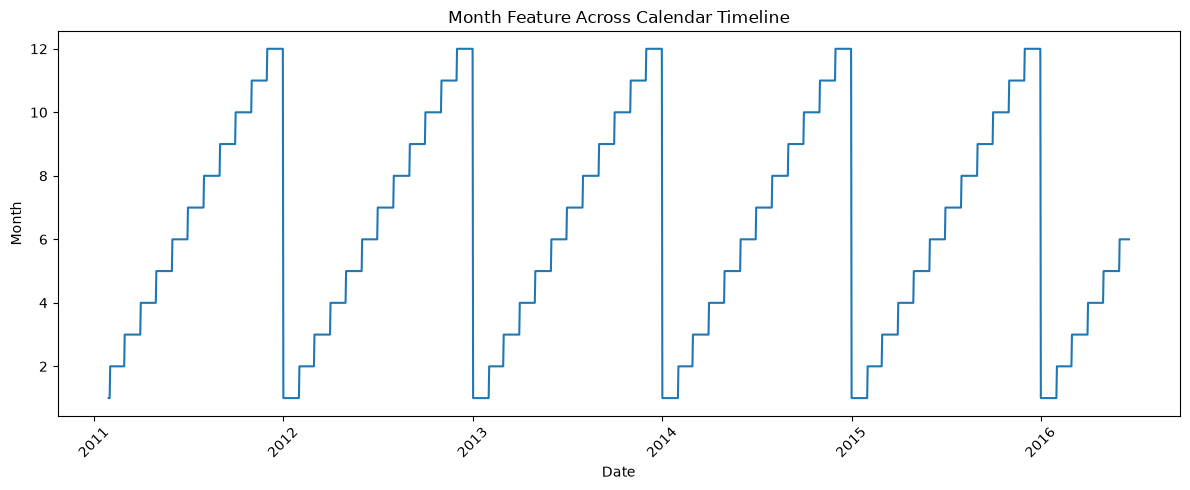

In [112]:
plt.figure(figsize=(12, 5))

plt.plot(
    calendar_features["date"],
    calendar_features["month_feature"]
)

plt.title("Month Feature Across Calendar Timeline")
plt.xlabel("Date")
plt.ylabel("Month")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [113]:
event_summary = pd.DataFrame({
    "event_name_1_non_none": [
        (calendar_features["event_name_1"] != "None").sum()
    ],
    "event_name_2_non_none": [
        (calendar_features["event_name_2"] != "None").sum()
    ]
}, index=[0])

display(event_summary)

print(
    calendar_features[
        calendar_features["event_name_1"] != "None"
    ][
        [
            "date",
            "event_name_1",
            "event_type_1"
        ]
    ].head(20)
)

,event_name_1_non_none,event_name_2_non_none
0,1969,1969


         date   event_name_1 event_type_1
0  2011-01-29            NaN          NaN
1  2011-01-30            NaN          NaN
2  2011-01-31            NaN          NaN
3  2011-02-01            NaN          NaN
4  2011-02-02            NaN          NaN
5  2011-02-03            NaN          NaN
6  2011-02-04            NaN          NaN
7  2011-02-05            NaN          NaN
8  2011-02-06      SuperBowl     Sporting
9  2011-02-07            NaN          NaN
10 2011-02-08            NaN          NaN
11 2011-02-09            NaN          NaN
12 2011-02-10            NaN          NaN
13 2011-02-11            NaN          NaN
14 2011-02-12            NaN          NaN
15 2011-02-13            NaN          NaN
16 2011-02-14  ValentinesDay     Cultural
17 2011-02-15            NaN          NaN
18 2011-02-16            NaN          NaN
19 2011-02-17            NaN          NaN


In [114]:
snap_columns = [
    "snap_CA",
    "snap_TX",
    "snap_WI"
]

print(
    calendar_features[snap_columns].sum()
)

print(
    calendar_features[snap_columns].value_counts()
    .head(10)
)

snap_CA    650
snap_TX    650
snap_WI    650
dtype: int64
snap_CA  snap_TX  snap_WI
0        0        0          994
1        1        1          260
0        1        1          195
1        1        0          130
         0        1          130
                  0          130
0        1        0           65
         0        1           65
Name: count, dtype: int64


In [115]:
feature_file = SRC_PATH / "feature_engineering.py"

current_code = feature_file.read_text(
    encoding="utf-8"
)

validation_function = '''

def validate_calendar_features(calendar):
    """
    Validate engineered calendar features.
    """

    required_features = [
        "year_feature",
        "month_feature",
        "day_feature",
        "day_of_week_feature",
        "quarter_feature",
        "week_of_year_feature",
        "is_weekend",
        "is_month_start",
        "is_month_end",
        "is_quarter_start",
        "is_quarter_end",
        "is_year_start",
        "is_year_end"
    ]

    missing_features = [
        feature
        for feature in required_features
        if feature not in calendar.columns
    ]

    validation = {
        "rows": len(calendar),
        "columns": len(calendar.columns),
        "missing_dates": int(
            calendar["date"].isna().sum()
        ),
        "duplicate_dates": int(
            calendar["date"].duplicated().sum()
        ),
        "dates_sorted": bool(
            calendar["date"].is_monotonic_increasing
        ),
        "missing_required_features": len(
            missing_features
        ),
        "invalid_month_values": int(
            (~calendar["month_feature"].between(1, 12)).sum()
        ),
        "invalid_day_of_week_values": int(
            (~calendar["day_of_week_feature"].between(0, 6)).sum()
        ),
        "invalid_quarter_values": int(
            (~calendar["quarter_feature"].between(1, 4)).sum()
        )
    }

    validation["missing_feature_names"] = missing_features

    return validation
'''

if "def validate_calendar_features" not in current_code:
    feature_file.write_text(
        current_code + validation_function,
        encoding="utf-8"
    )

    print("validate_calendar_features() added successfully.")
else:
    print("validate_calendar_features() already exists.")

validate_calendar_features() already exists.


In [116]:
importlib.reload(feature_engineering)

from feature_engineering import validate_calendar_features

calendar_validation = validate_calendar_features(
    calendar_features
)

print("Calendar Feature Validation")
print("=" * 60)

for key, value in calendar_validation.items():
    print(f"{key}: {value}")

Calendar Feature Validation
rows: 1969
columns: 27
missing_dates: 0
duplicate_dates: 0
dates_sorted: True
missing_required_features: 0
invalid_month_values: 0
invalid_day_of_week_values: 0
invalid_quarter_values: 0
missing_feature_names: []


In [117]:
feature_output_path = (
    PROCESSED_PATH
    / "calendar_features.csv"
)
feature_output_path.parent.mkdir(parents=True, exist_ok=True)

calendar_features.to_csv(
    feature_output_path,
    index=False
)

print(
    "Saved:",
    feature_output_path
)

Saved: E:\dl-assignment\data\m5\processed\calendar_features.csv


In [118]:
validation_output_path = (
    RESULTS_PATH / "calendar_feature_validation.csv"
)
validation_output_path.parent.mkdir(parents=True, exist_ok=True)

pd.DataFrame([calendar_validation]).to_csv(
    validation_output_path,
    index=False
)

print(
    "Saved:",
    validation_output_path
)

Saved: E:\dl-assignment\results\calendar_feature_validation.csv


In [119]:
assert calendar_validation["missing_dates"] == 0
assert calendar_validation["duplicate_dates"] == 0
assert calendar_validation["dates_sorted"] is True
assert calendar_validation["missing_required_features"] == 0
assert calendar_validation["invalid_month_values"] == 0
assert calendar_validation["invalid_day_of_week_values"] == 0
assert calendar_validation["invalid_quarter_values"] == 0

print("All calendar feature-engineering checks passed.")

All calendar feature-engineering checks passed.


In [120]:
print("Final Calendar Feature Set")
print("=" * 60)

for i, column in enumerate(calendar_features.columns, start=1):
    print(f"{i:02d}. {column}")

Final Calendar Feature Set
01. date
02. wm_yr_wk
03. weekday
04. wday
05. month
06. year
07. d
08. event_name_1
09. event_type_1
10. event_name_2
11. event_type_2
12. snap_CA
13. snap_TX
14. snap_WI
15. year_feature
16. month_feature
17. day_feature
18. day_of_week_feature
19. quarter_feature
20. week_of_year_feature
21. is_weekend
22. is_month_start
23. is_month_end
24. is_quarter_start
25. is_quarter_end
26. is_year_start
27. is_year_end


# Lag Feature Engineering

## Objective

This notebook extends the calendar-based feature engineering pipeline by
creating historical demand lag features from the M5 sales data.

Lag features represent previous demand observations and allow the deep
learning models to learn temporal dependencies.

The following lag periods are considered:

- 1 day
- 7 days
- 14 days
- 28 days
- 56 days

## Leakage Prevention

Lag features are generated exclusively from observations occurring before
the prediction date.

For example:

- lag_1 uses demand from the previous day
- lag_7 uses demand from seven days earlier
- lag_28 uses demand from 28 days earlier

The current-day target is never used to calculate its own lag features.

The chronological train/validation/test split and train-only scaling will
be implemented in later commits.

In [121]:
sales_clean = pd.read_csv(
    PROCESSED_PATH / "sales_train_validation_clean.csv"
)

print("Sales shape:", sales_clean.shape)

Sales shape: (30490, 1919)


In [122]:
sales_columns = [
    column for column in sales_clean.columns
    if column.startswith("d_")
]

print("Number of daily demand columns:", len(sales_columns))
print("First 5:", sales_columns[:5])
print("Last 5:", sales_columns[-5:])

Number of daily demand columns: 1913
First 5: ['d_1', 'd_2', 'd_3', 'd_4', 'd_5']
Last 5: ['d_1909', 'd_1910', 'd_1911', 'd_1912', 'd_1913']


## Understanding Lag Features

For a target at day `t`:

| Feature | Meaning |
|---|---|
| lag_1 | demand at t-1 |
| lag_7 | demand at t-7 |
| lag_14 | demand at t-14 |
| lag_28 | demand at t-28 |
| lag_56 | demand at t-56 |

For example, if predicting demand for `d_100`:

- lag_1 → `d_99`
- lag_7 → `d_93`
- lag_14 → `d_86`
- lag_28 → `d_72`
- lag_56 → `d_44`

Therefore, none of these features contain the target value at `d_100`.

In [123]:
import importlib
import feature_engineering

importlib.reload(feature_engineering)

from feature_engineering import (
    get_sales_columns,
    create_lag_features,
    validate_lag_features
)

print("Feature-engineering functions reloaded successfully.")

Feature-engineering functions reloaded successfully.


In [124]:
lag_days = (1, 7, 14, 28, 56)

lag_features = create_lag_features(
    sales_clean,
    lag_days=lag_days
)

print("Generated lag features:")
for lag, data in lag_features.items():
    print(f"lag_{lag}: {data.shape}")

Generated lag features:
lag_1: (30490, 1913)
lag_7: (30490, 1913)
lag_14: (30490, 1913)
lag_28: (30490, 1913)
lag_56: (30490, 1913)


In [125]:
series_index = 0

original = sales_clean.loc[series_index, sales_columns]

print("Original demand:")
print(original.iloc[:10].to_string())

lag_1 = lag_features[1].loc[series_index]

comparison = pd.DataFrame({
    "original": original.iloc[:10].values,
    "lag_1": lag_1.iloc[:10].values
})

display(comparison)

Original demand:
d_1     0
d_2     0
d_3     0
d_4     0
d_5     0
d_6     0
d_7     0
d_8     0
d_9     0
d_10    0


,original,lag_1
0,0,NaN
1,0,0.0
2,0,0.0
3,0,0.0
4,0,0.0
5,0,0.0
6,0,0.0
7,0,0.0
8,0,0.0
9,0,0.0


In [126]:
lag_7 = lag_features[7].loc[series_index]

comparison_7 = pd.DataFrame({
    "original": original.iloc[:15].values,
    "lag_7": lag_7.iloc[:15].values
})

display(comparison_7)

,original,lag_7
0,0,NaN
1,0,NaN
2,0,NaN
3,0,NaN
4,0,NaN
5,0,NaN
6,0,NaN
7,0,0.0
8,0,0.0
9,0,0.0


In [127]:
for lag in lag_days:
    lag_data = lag_features[lag]

    first_column_missing = lag_data.iloc[:, :lag].isna().sum().sum()

    print(
        f"lag_{lag}: "
        f"missing values in first {lag} time positions = "
        f"{first_column_missing:,}"
    )

lag_1: missing values in first 1 time positions = 30,490
lag_7: missing values in first 7 time positions = 213,430
lag_14: missing values in first 14 time positions = 426,860
lag_28: missing values in first 28 time positions = 853,720
lag_56: missing values in first 56 time positions = 1,707,440


In [128]:
lag_validation = validate_lag_features(
    sales_clean,
    lag_features,
    lag_days=lag_days
)

lag_validation_df = pd.DataFrame(
    list(lag_validation.items()),
    columns=["validation_check", "value"]
)

display(lag_validation_df)

,validation_check,value
0,number_of_series,30490
1,number_of_days,1913
2,lag_count,5
3,lags,"[1, 7, 14, 28, 56]"
4,lag_1_shape_valid,True
5,lag_1_initial_nan_count,30490
6,lag_1_contains_current_target,False
7,lag_7_shape_valid,True
8,lag_7_initial_nan_count,213430
9,lag_7_contains_current_target,False


In [129]:
for lag in lag_days:
    lag_data = lag_features[lag]

    for current_position in range(lag, min(lag + 10, len(sales_columns))):
        source_position = current_position - lag

        current_column = sales_columns[current_position]
        source_column = sales_columns[source_position]

        current_value = lag_data.iloc[0, current_position]
        expected_value = sales_clean.iloc[0][source_column]

        assert current_value == expected_value, (
            f"Lag {lag} validation failed at {current_column}"
        )

print("All lag alignment checks passed.")

All lag alignment checks passed.


In [130]:
for lag in lag_days:
    for position in range(lag, min(lag + 20, len(sales_columns))):
        lag_value = lag_features[lag].iloc[0, position]
        target_value = sales_clean.iloc[0, position]

        if pd.notna(lag_value):
            source_position = position - lag

            assert source_position < position, (
                f"Potential leakage detected for lag {lag}"
            )

print("Leakage check passed: all lag features use earlier observations.")

Leakage check passed: all lag features use earlier observations.


In [131]:
daily_total_demand = sales_clean[sales_columns].sum(axis=0)

daily_total_demand = pd.Series(
    daily_total_demand.values,
    index=range(1, len(sales_columns) + 1),
    name="total_demand"
)

lag_correlation_results = []

for lag in lag_days:
    correlation = (
        daily_total_demand
        .corr(daily_total_demand.shift(lag))
    )

    lag_correlation_results.append({
        "lag_days": lag,
        "correlation": correlation
    })

lag_correlation_df = pd.DataFrame(lag_correlation_results)

display(lag_correlation_df)

,lag_days,correlation
0,1,0.674229
1,7,0.812189
2,14,0.744354
3,28,0.840348
4,56,0.767576


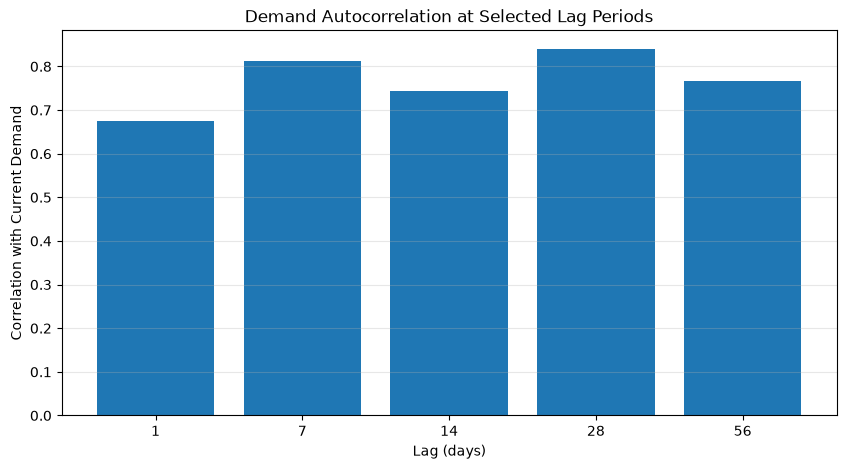

In [132]:
plt.figure(figsize=(10, 5))

plt.bar(
    lag_correlation_df["lag_days"].astype(str),
    lag_correlation_df["correlation"]
)

plt.xlabel("Lag (days)")
plt.ylabel("Correlation with Current Demand")
plt.title("Demand Autocorrelation at Selected Lag Periods")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [133]:
lag_correlation_path = (
    RESULTS_PATH / "lag_correlation_analysis.csv"
)

lag_correlation_df.to_csv(
    lag_correlation_path,
    index=False
)

print("Saved:", lag_correlation_path)

Saved: E:\dl-assignment\results\lag_correlation_analysis.csv


In [134]:
lag_validation_path = (
    RESULTS_PATH / "lag_feature_validation.csv"
)

lag_validation_df.to_csv(
    lag_validation_path,
    index=False
)

print("Saved:", lag_validation_path)

Saved: E:\dl-assignment\results\lag_feature_validation.csv


## Conclusion

Lag features were successfully implemented for the M5 demand data using
1-day, 7-day, 14-day, 28-day, and 56-day historical periods.

The implementation was validated using direct alignment checks. Each lag
references only an earlier observation and therefore does not introduce
future target information.

The initial missing values created by each lag are structural because the
required historical observations do not exist at the beginning of the
series. They will be handled appropriately during sequence generation.

The lag matrices are not permanently stored because the full M5 dataset is
large. Instead, the lag generation logic is retained in the reusable
feature-engineering module and will be integrated into the later
sequence-generation pipeline.

Chronological train/validation/test splitting and train-only scaling will
be implemented in subsequent commits.

# Rolling Statistical Feature Engineering

## Objective

This section creates historical rolling statistical features from the M5
daily demand data.

Rolling statistics summarize recent demand behaviour over predefined
historical windows.

The following features are considered:

- 7-day rolling mean
- 14-day rolling mean
- 28-day rolling mean
- 7-day rolling standard deviation
- 28-day rolling standard deviation

## Leakage Prevention

Rolling statistics must only contain observations that were available before
the prediction date.

Therefore, the demand series is shifted by one time step before calculating
the rolling statistic:

    shift(1).rolling(window)

For a prediction at time t, a 7-day rolling mean therefore uses:

    t-7, t-6, ..., t-1

and does not use the target at time t.

The test dataset will remain completely isolated from model selection and
hyperparameter tuning in later stages.

In [135]:
import importlib
import feature_engineering

importlib.reload(feature_engineering)

from feature_engineering import (
    get_sales_columns,
    create_rolling_features,
    validate_rolling_features
)

In [136]:
rolling_windows = (7, 14, 28)

rolling_features = create_rolling_features(
    sales_clean,
    rolling_windows=rolling_windows
)

print("Generated rolling features:")

for feature_name, data in rolling_features.items():
    print(
        f"{feature_name}: {data.shape}"
    )

Generated rolling features:
rolling_mean_7: (30490, 1913)
rolling_std_7: (30490, 1913)
rolling_mean_14: (30490, 1913)
rolling_std_14: (30490, 1913)
rolling_mean_28: (30490, 1913)
rolling_std_28: (30490, 1913)


In [137]:
series_index = 0

original = sales_clean.loc[
    series_index,
    sales_columns
]

rolling_mean_7 = rolling_features[
    "rolling_mean_7"
].loc[series_index]

comparison = pd.DataFrame({
    "original": original.iloc[:15].values,
    "rolling_mean_7": rolling_mean_7.iloc[:15].values
})

display(comparison)

,original,rolling_mean_7
0,0,NaN
1,0,NaN
2,0,NaN
3,0,NaN
4,0,NaN
5,0,NaN
6,0,NaN
7,0,0.0
8,0,0.0
9,0,0.0


In [138]:
position = 7

expected_mean = original.iloc[
    position - 7:position
].mean()

actual_mean = rolling_mean_7.iloc[position]

print("Expected:", expected_mean)
print("Actual:  ", actual_mean)

assert np.isclose(
    expected_mean,
    actual_mean,
    equal_nan=True
)

print("7-day rolling mean calculation verified.")

Expected: 0.0
Actual:   0.0
7-day rolling mean calculation verified.


In [139]:
rolling_mean_14 = rolling_features[
    "rolling_mean_14"
].loc[series_index]

position = 14

expected_mean_14 = original.iloc[
    position - 14:position
].mean()

actual_mean_14 = rolling_mean_14.iloc[position]

print("Expected:", expected_mean_14)
print("Actual:  ", actual_mean_14)

assert np.isclose(
    expected_mean_14,
    actual_mean_14,
    equal_nan=True
)

print("14-day rolling mean calculation verified.")

Expected: 0.0
Actual:   0.0
14-day rolling mean calculation verified.


In [140]:
rolling_mean_28 = rolling_features[
    "rolling_mean_28"
].loc[series_index]

position = 28

expected_mean_28 = original.iloc[
    position - 28:position
].mean()

actual_mean_28 = rolling_mean_28.iloc[position]

print("Expected:", expected_mean_28)
print("Actual:  ", actual_mean_28)

assert np.isclose(
    expected_mean_28,
    actual_mean_28,
    equal_nan=True
)

print("28-day rolling mean calculation verified.")

Expected: 0.0
Actual:   0.0
28-day rolling mean calculation verified.


In [141]:
rolling_std_7 = rolling_features[
    "rolling_std_7"
].loc[series_index]

position = 7

expected_std_7 = original.iloc[
    position - 7:position
].std()

actual_std_7 = rolling_std_7.iloc[position]

print("Expected:", expected_std_7)
print("Actual:  ", actual_std_7)

assert np.isclose(
    expected_std_7,
    actual_std_7,
    equal_nan=True
)

print("7-day rolling standard deviation verified.")

Expected: 0.0
Actual:   0.0
7-day rolling standard deviation verified.


In [142]:
rolling_validation = validate_rolling_features(
    sales_clean,
    rolling_features,
    rolling_windows=rolling_windows
)

rolling_validation_df = pd.DataFrame(
    list(rolling_validation.items()),
    columns=[
        "validation_check",
        "value"
    ]
)

display(rolling_validation_df)

,validation_check,value
0,number_of_series,30490
1,number_of_days,1913
2,rolling_window_count,3
3,rolling_windows,"[7, 14, 28]"
4,rolling_mean_7_shape_valid,True
5,rolling_std_7_shape_valid,True
6,rolling_mean_7_initial_missing_positions,7
7,rolling_std_7_initial_missing_positions,7
8,rolling_mean_7_expected_initial_missing_positions,7
9,rolling_std_7_expected_initial_missing_positions,7


In [143]:
for window in rolling_windows:

    rolling_mean = rolling_features[
        f"rolling_mean_{window}"
    ].loc[series_index]

    rolling_std = rolling_features[
        f"rolling_std_{window}"
    ].loc[series_index]

    for position in range(
        window,
        min(window + 20, len(sales_columns))
    ):

        # Historical range ends immediately BEFORE current position.
        historical_values = original.iloc[
            position - window:position
        ]

        expected_mean = historical_values.mean()
        expected_std = historical_values.std()

        actual_mean = rolling_mean.iloc[
            position
        ]

        actual_std = rolling_std.iloc[
            position
        ]

        assert np.isclose(
            expected_mean,
            actual_mean,
            equal_nan=True
        )

        assert np.isclose(
            expected_std,
            actual_std,
            equal_nan=True
        )

print(
    "Leakage test passed: "
    "all rolling statistics use only historical observations."
)

Leakage test passed: all rolling statistics use only historical observations.


In [144]:
position = 28
window = 7

historical_range = list(
    range(position - window, position)
)

print("Current target position:", position)
print("Historical positions used:", historical_range)
print("Current target included:", position in historical_range)

Current target position: 28
Historical positions used: [21, 22, 23, 24, 25, 26, 27]
Current target included: False


In [145]:
daily_total_demand = sales_clean[
    sales_columns
].sum(axis=0)

daily_total_demand = pd.Series(
    daily_total_demand.values,
    index=range(1, len(sales_columns) + 1),
    name="total_demand"
)

display(daily_total_demand.head())

1    32631
2    31749
3    23783
4    25412
5    19146
Name: total_demand, dtype: int64

In [146]:
aggregate_rolling = pd.DataFrame({
    "total_demand": daily_total_demand
})

aggregate_rolling["rolling_mean_7"] = (
    daily_total_demand
    .shift(1)
    .rolling(7)
    .mean()
)

aggregate_rolling["rolling_mean_14"] = (
    daily_total_demand
    .shift(1)
    .rolling(14)
    .mean()
)

aggregate_rolling["rolling_mean_28"] = (
    daily_total_demand
    .shift(1)
    .rolling(28)
    .mean()
)

aggregate_rolling["rolling_std_7"] = (
    daily_total_demand
    .shift(1)
    .rolling(7)
    .std()
)

aggregate_rolling["rolling_std_28"] = (
    daily_total_demand
    .shift(1)
    .rolling(28)
    .std()
)

display(aggregate_rolling.head(35))

,total_demand,rolling_mean_7,rolling_mean_14,rolling_mean_28,rolling_std_7,rolling_std_28
1,32631,NaN,NaN,NaN,NaN,NaN
2,31749,NaN,NaN,NaN,NaN,NaN
3,23783,NaN,NaN,NaN,NaN,NaN
4,25412,NaN,NaN,NaN,NaN,NaN
5,19146,NaN,NaN,NaN,NaN,NaN
6,29211,NaN,NaN,NaN,NaN,NaN
7,28010,NaN,NaN,NaN,NaN,NaN
8,37932,27134.571429,NaN,NaN,4736.369315,NaN
9,32736,27891.857143,NaN,NaN,6013.298192,NaN
10,25572,28032.857143,NaN,NaN,6129.267668,NaN


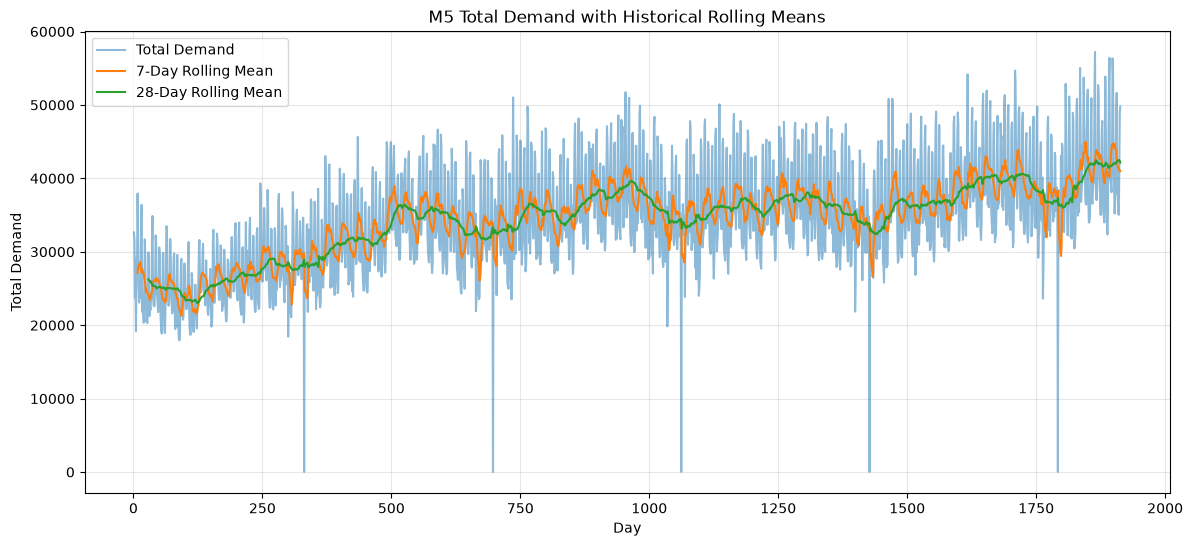

In [147]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    aggregate_rolling.index,
    aggregate_rolling["total_demand"],
    label="Total Demand",
    alpha=0.5
)

plt.plot(
    aggregate_rolling.index,
    aggregate_rolling["rolling_mean_7"],
    label="7-Day Rolling Mean"
)

plt.plot(
    aggregate_rolling.index,
    aggregate_rolling["rolling_mean_28"],
    label="28-Day Rolling Mean"
)

plt.xlabel("Day")
plt.ylabel("Total Demand")
plt.title(
    "M5 Total Demand with Historical Rolling Means"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

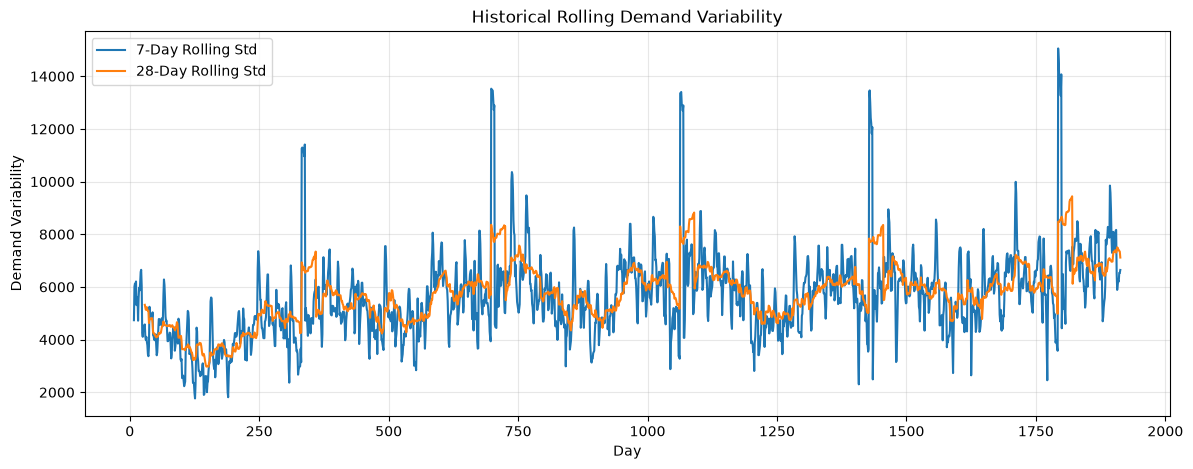

In [148]:
plt.figure(figsize=(14, 5))

plt.plot(
    aggregate_rolling.index,
    aggregate_rolling["rolling_std_7"],
    label="7-Day Rolling Std"
)

plt.plot(
    aggregate_rolling.index,
    aggregate_rolling["rolling_std_28"],
    label="28-Day Rolling Std"
)

plt.xlabel("Day")
plt.ylabel("Demand Variability")
plt.title(
    "Historical Rolling Demand Variability"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [149]:
rolling_analysis_path = (
    RESULTS_PATH /
    "rolling_demand_analysis.csv"
)

aggregate_rolling.to_csv(
    rolling_analysis_path,
    index=False
)

print(
    "Saved:",
    rolling_analysis_path
)

Saved: E:\dl-assignment\results\rolling_demand_analysis.csv


In [150]:
rolling_validation_path = (
    RESULTS_PATH /
    "rolling_feature_validation.csv"
)

rolling_validation_df.to_csv(
    rolling_validation_path,
    index=False
)

print(
    "Saved:",
    rolling_validation_path
)

Saved: E:\dl-assignment\results\rolling_feature_validation.csv


In [151]:
rolling_summary = pd.DataFrame({
    "feature": [
        "rolling_mean_7",
        "rolling_mean_14",
        "rolling_mean_28",
        "rolling_std_7",
        "rolling_std_28"
    ],
    "window_days": [
        7,
        14,
        28,
        7,
        28
    ],
    "purpose": [
        "Recent demand level",
        "Short-to-medium demand level",
        "Medium-term demand level",
        "Recent demand variability",
        "Medium-term demand variability"
    ]
})

rolling_summary.to_csv(
    RESULTS_PATH / "rolling_feature_summary.csv",
    index=False
)
display(rolling_summary)

,feature,window_days,purpose
0,rolling_mean_7,7,Recent demand level
1,rolling_mean_14,14,Short-to-medium demand level
2,rolling_mean_28,28,Medium-term demand level
3,rolling_std_7,7,Recent demand variability
4,rolling_std_28,28,Medium-term demand variability


## Conclusion

Historical rolling demand statistics were successfully engineered using
7-day, 14-day, and 28-day windows.

The following features were implemented:

- rolling_mean_7
- rolling_mean_14
- rolling_mean_28
- rolling_std_7
- rolling_std_28

To prevent target leakage, every rolling statistic is calculated using a
one-step shifted demand series. Therefore, the target value at time t is
never included in its own rolling feature.

Manual calculations and automated leakage tests confirmed that the rolling
features use only historical observations.

The rolling features provide information about recent demand level and
demand variability and complement the individual lag features created in
Commit 12.

The chronological train/validation/test split will be performed before
model training. Scaling parameters will subsequently be learned only from
the training data.